# 02 – LSTM (v4): training and backtest

Reads `datos_finales_IA.csv` (produced by notebook 01), splits chronologically 80/20, fits a `StandardScaler` on the
**training part only**, builds 60-bar sequences and trains a small LSTM (1 layer, 32 hidden units, dropout 0.5, weight decay 1e-5).
Then runs three simple backtests on the held-out 20 %: long-only, and long/short with commission (0.15 %) and borrow cost (20 % APR).

Read the results with the limitations listed in the repository README (single test window in a falling market, short-biased
predictions, thresholds chosen after looking at the prediction range, no walk-forward validation).

In [8]:
import yfinance as yf
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler # <--- El cambio clave

# 1. CARGAR DATOS
df = pd.read_csv('datos_finales_IA.csv', index_col=0, parse_dates=True)
feature_cols = [c for c in df.columns if c != 'Target']
X = df[feature_cols].values
y = df['Target'].values

# 2. DIVISIÓN TEMPORAL ESTRICTA (Antes de escalar)
split_idx = int(len(X) * 0.8)

X_train_raw = X[:split_idx]
X_test_raw = X[split_idx:]
y_train = y[:split_idx]
y_test = y[split_idx:]

# 2. ESCALADO ROBUSTO (STANDARD SCALER)
# Z-Score Normalization: (x - media) / desviacion_estandar
# Esto centra los datos en 0 y permite que los outliers (crash) existan
# sin aplastar el resto de datos.
scaler = StandardScaler()
scaler.fit(X_train_raw) # Aprendemos la "física" del pasado

X_train_scaled = scaler.transform(X_train_raw)
X_test_scaled = scaler.transform(X_test_raw) # Aplicamos al futuro

# 4. CREAR SECUENCIAS (Igual que antes)
def create_sequences(data, target, window_size):
    xs, ys = [], []
    for i in range(len(data) - window_size):
        x_block = data[i : i+window_size]
        y_point = target[i+window_size]
        xs.append(x_block)
        ys.append(y_point)
    return np.array(xs), np.array(ys)

WINDOW_SIZE = 60
X_train, y_train_seq = create_sequences(X_train_scaled, y_train, WINDOW_SIZE)
X_test, y_test_seq = create_sequences(X_test_scaled, y_test, WINDOW_SIZE) # Aquí perdemos las primeras 60 horas del test, es normal

# 5. TENSORES
train_data = TensorDataset(torch.from_numpy(X_train).float(), torch.from_numpy(y_train_seq).float())
test_data = TensorDataset(torch.from_numpy(X_test).float(), torch.from_numpy(y_test_seq).float())

BATCH_SIZE = 32
train_loader = DataLoader(train_data, shuffle=True, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_data, shuffle=False, batch_size=BATCH_SIZE)

print("Datos re-procesados correctamente (Sin Data Leakage).")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")

Datos re-procesados correctamente (Sin Data Leakage).
Train shape: (2643, 60, 6), Test shape: (616, 60, 6)


In [10]:
import torch
import torch.nn as nn

# --- ESTA ES LA PARTE QUE FALTA (TAREA 5) ---

# 1. DEFINIR LA ARQUITECTURA (El Plano del edificio)
class TradingBotLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim=1):
        super(TradingBotLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        # 1. LSTM: Ponemos dropout=0 aquí para quitar el warning.
        # Al ser 1 sola capa, el dropout interno no sirve.
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0)
        
        # 2. DROPOUT MANUAL: Esta es la capa que "apaga" neuronas
        self.dropout = nn.Dropout(0.5) 
        
        # 3. Capa lineal final
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        # Inicializar memoria a ceros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        
        # Pasada por la LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Nos quedamos con el último paso temporal
        out = out[:, -1, :]
        
        # --- AQUÍ APLICAMOS EL DROPOUT ---
        # Justo antes de la decisión final. Esto obliga a la red a ser robusta.
        out = self.dropout(out)
        
        # Decisión final
        out = self.fc(out)
        return self.sigmoid(out)

# Instanciamos el modelo simplificado
INPUT_DIM = 6
HIDDEN_DIM = 32  # Reducido
NUM_LAYERS = 1   # Reducido

model = TradingBotLSTM(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS)
print("Modelo simplificado listo (con Dropout manual activo).")

Modelo simplificado listo (con Dropout manual activo).


In [11]:
import torch.optim as optim

# 1. CONFIGURACIÓN DEL "EXPERIMENTO"
# Definimos la función de error y el optimizador
criterion = nn.BCELoss() # Binary Cross Entropy Loss
learning_rate = 0.001    # Qué tan grandes son los pasos que da el gradiente
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)

# Listas para guardar el historial (para luego graficar)
train_losses = []
val_losses = []
train_accs = []
val_accs = []

# 2. EL BUCLE DE ENTRENAMIENTO
NUM_EPOCHS = 10 # Número de veces que el modelo verá los datos completos

print(f"Iniciando entrenamiento por {NUM_EPOCHS} épocas...")

for epoch in range(NUM_EPOCHS):
    # --- FASE DE ENTRENAMIENTO ---
    model.train() # Pone el modelo en modo "aprender" (activa Dropout)
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for X_batch, y_batch in train_loader:
        # A. Resetear gradientes (si no, se acumulan)
        optimizer.zero_grad()
        
        # B. Forward Pass (Predicción)
        y_pred = model(X_batch)
        
        # C. Calcular Error
        # Ajustamos dimensiones: y_batch debe ser (Batch, 1) igual que y_pred
        loss = criterion(y_pred, y_batch.unsqueeze(1))
        
        # D. Backward Pass (Calcular derivadas)
        loss.backward()
        
        # E. Optimizar (Actualizar pesos)
        optimizer.step()
        
        # Estadísticas
        running_loss += loss.item()
        predicted = (y_pred > 0.5).float() # Si prob > 0.5 es 1, si no 0
        correct_train += (predicted == y_batch.unsqueeze(1)).sum().item()
        total_train += y_batch.size(0)
        
    # --- FASE DE VALIDACIÓN (EXAMEN) ---
    model.eval() # Pone el modelo en modo "evaluar" (apaga Dropout)
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    with torch.no_grad(): # No calculamos gradientes aquí (ahorra memoria)
        for X_val, y_val in test_loader:
            y_pred_val = model(X_val)
            loss_val = criterion(y_pred_val, y_val.unsqueeze(1))
            
            val_loss += loss_val.item()
            predicted_val = (y_pred_val > 0.5).float()
            correct_val += (predicted_val == y_val.unsqueeze(1)).sum().item()
            total_val += y_val.size(0)
    
    # Calcular promedios
    epoch_train_loss = running_loss / len(train_loader)
    epoch_val_loss = val_loss / len(test_loader)
    epoch_train_acc = correct_train / total_train
    epoch_val_acc = correct_val / total_val
    
    # Guardar historia
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accs.append(epoch_train_acc)
    val_accs.append(epoch_val_acc)
    
    # Imprimir progreso cada 5 épocas
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
              f"Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | "
              f"Train Acc: {epoch_train_acc:.2%} | Val Acc: {epoch_val_acc:.2%}")

print("Entrenamiento finalizado.")

Iniciando entrenamiento por 10 épocas...
Epoch 5/10 | Train Loss: 0.6737 | Val Loss: 0.6409 | Train Acc: 57.93% | Val Acc: 66.72%
Epoch 10/10 | Train Loss: 0.6695 | Val Loss: 0.6579 | Train Acc: 58.34% | Val Acc: 63.47%
Entrenamiento finalizado.


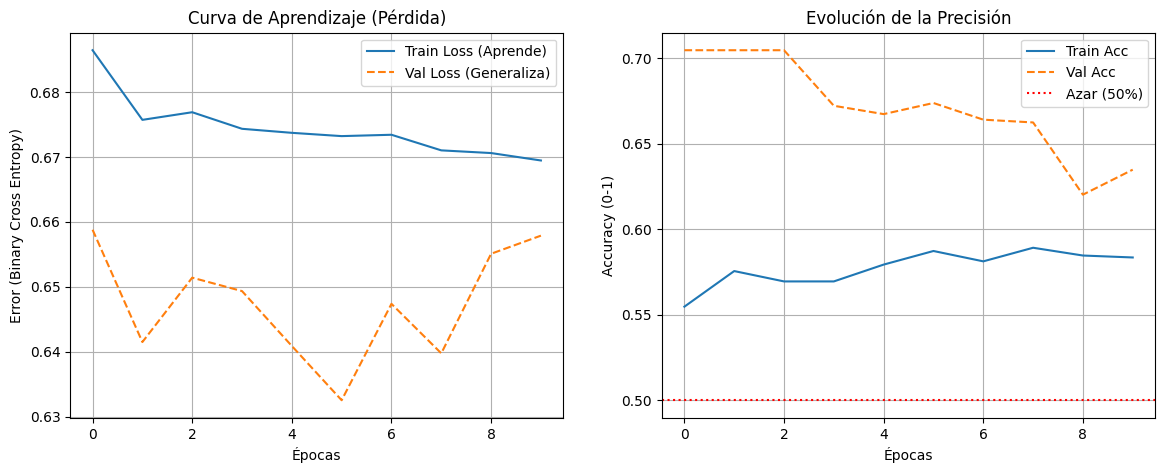

Precisión Final en Test: 63.47%


In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Gráfica de PÉRDIDA (Loss)
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss (Aprende)')
plt.plot(val_losses, label='Val Loss (Generaliza)', linestyle='--')
plt.title('Curva de Aprendizaje (Pérdida)')
plt.xlabel('Épocas')
plt.ylabel('Error (Binary Cross Entropy)')
plt.legend()
plt.grid(True)

# Gráfica de PRECISIÓN (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc', linestyle='--')
plt.title('Evolución de la Precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy (0-1)')
plt.axhline(0.5, color='r', linestyle=':', label='Azar (50%)') # Línea base
plt.legend()
plt.grid(True)

plt.show()

print(f"Precisión Final en Test: {val_accs[-1]:.2%}")

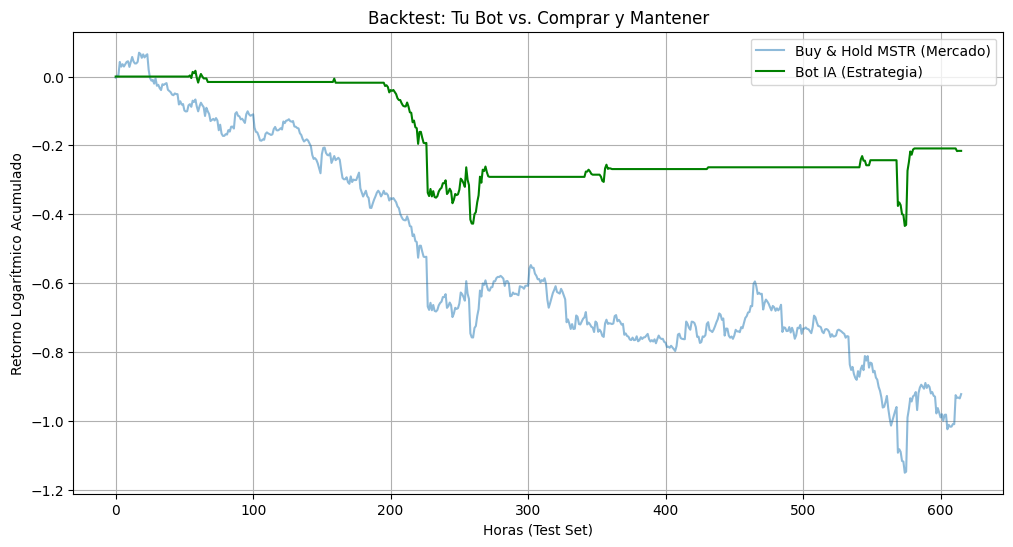

Retorno Total del Bot en el periodo: -0.2159 (aprox -21.59%)
Retorno del Mercado (MSTR) en el periodo: -0.9228


In [13]:
#TEST 1: solo longs con prob > 0.5

import matplotlib.pyplot as plt
import numpy as np

# 1. OBTENER PREDICCIONES DEL MODELO
model.eval()
predictions = []
actuals = []

# Pasamos los datos de test por el modelo
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        y_pred = model(X_batch)
        predictions.extend(y_pred.squeeze().tolist())
        actuals.extend(y_batch.tolist())

# Convertimos a arrays
predictions = np.array(predictions)
actuals = np.array(actuals)

# 2. SIMULACIÓN DE TRADING (BACKTEST SIMPLE)
# Señal: Si prob > 0.5 Compramos (1), si no Vendemos/Esperamos (0)
# Para hacerlo más agresivo: Si prob > 0.6 Compramos, si prob < 0.4 Vendemos
signals = (predictions > 0.5).astype(int)

# Recuperamos los retornos reales del mercado (necesitamos volver al DataFrame original)
# Truco: Usamos los últimos datos del dataframe original que corresponden al test
# El test son los últimos len(predictions) datos
market_returns = df['lret_mstr'].iloc[-len(predictions):].values
market_returns_btc = df['lret_btc'].iloc[-len(predictions):].values

# 3. CÁLCULO DE BENEFICIOS
# Estrategia: Si Señal es 1, ganamos el retorno de MSTR. Si es 0, nos quedamos en cash (retorno 0).
# (Asumimos que entramos Long. Para Short habría que multiplicar por -1)
strategy_returns = signals * market_returns

# Calculamos la curva de capital acumulada (Cumulative Returns)
cumulative_market = np.cumsum(market_returns)
cumulative_strategy = np.cumsum(strategy_returns)

# 4. VISUALIZACIÓN
plt.figure(figsize=(12, 6))
plt.plot(cumulative_market, label='Buy & Hold MSTR (Mercado)', alpha=0.5)
plt.plot(cumulative_strategy, label='Bot IA (Estrategia)', color='green')
plt.title('Backtest: Tu Bot vs. Comprar y Mantener')
plt.xlabel('Horas (Test Set)')
plt.ylabel('Retorno Logarítmico Acumulado')
plt.legend()
plt.grid(True)
plt.show()

# Métricas finales
total_return = cumulative_strategy[-1]
print(f"Retorno Total del Bot en el periodo: {total_return:.4f} (aprox {total_return*100:.2f}%)")
print(f"Retorno del Mercado (MSTR) en el periodo: {cumulative_market[-1]:.4f}")

Simulando operaciones con costes...


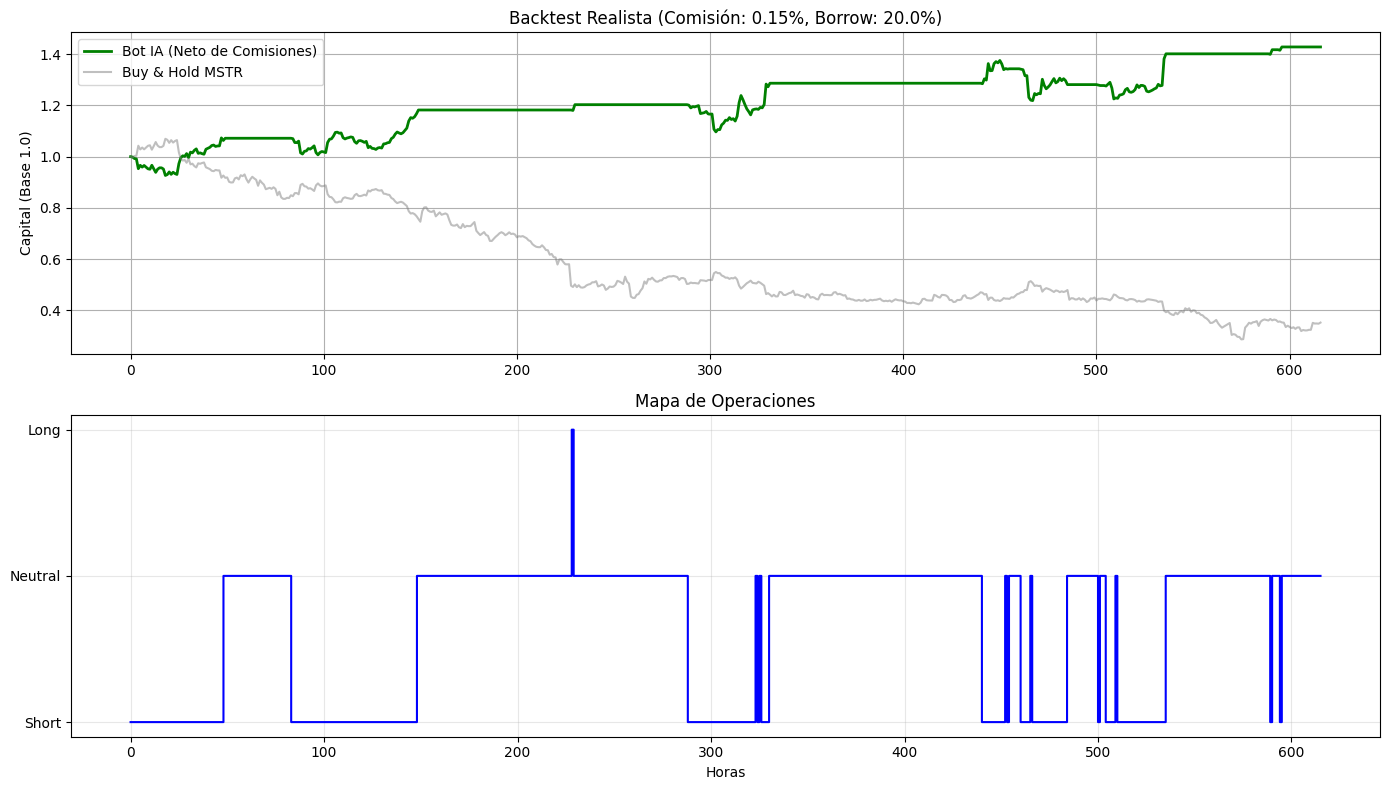

--- RESULTADOS REALISTAS ---
Capital Final: 1.4287 (Retorno: 42.87%)
Total Operaciones (Cambios de estado): 29
Coste estimado en comisiones: 4.35% del volumen rotado


In [19]:
#Test 3: Test 2 pero con comisiones y slippage

import matplotlib.pyplot as plt
import numpy as np

# 1. PARÁMETROS DE COSTES (El "Freno de Mano")
COMMISSION = 0.0015      # 0.15% por operación (incluye spread/slippage)
BORROW_RATE_ANNUAL = 0.20 # 20% anual por mantener shorts
HOURLY_BORROW_RATE = BORROW_RATE_ANNUAL / 365 / 24

# 2. OBTENER SEÑALES (Igual que antes)
# Reutilizamos las predicciones que ya calculaste en la Tarea 9
# predictions = ... (ya lo tienes en memoria)
# market_returns = ... (ya lo tienes en memoria)

# Umbrales
UPPER = 0.55
LOWER = 0.45

# 3. BUCLE DE SIMULACIÓN "EVENT-DRIVEN"
equity_curve = [1.0] # Empezamos con 100% del capital (normalizado a 1)
current_position = 0 # 0: Neutral, 1: Long, -1: Short
positions_history = [] # Para graficar luego cuándo estamos dentro

print("Simulando operaciones con costes...")

for i in range(len(predictions)):
    prob = predictions[i]
    r_market = market_returns[i]
    
    # A. Decidir la Señal del Modelo
    signal = 0
    if prob > UPPER: signal = 1
    elif prob < LOWER: signal = -1
    else: signal = 0
    
    # B. Calcular Costes de Transacción (Solo si cambiamos de posición)
    cost = 0
    if signal != current_position:
        # Pagamos comisión sobre el total de la posición
        # (Simplificación: asumimos reinversión total)
        cost = COMMISSION 
    
    # C. Calcular Retorno del Mercado según la posición ANTERIOR
    # (Ganamos/Perdemos por la posición que traíamos abierta)
    
    # Retorno base de la estrategia en esta hora
    hourly_return = 0
    
    if current_position == 1: # Estábamos Long
        hourly_return = r_market
    elif current_position == -1: # Estábamos Short
        hourly_return = -1 * r_market # Inverso del mercado
        hourly_return -= HOURLY_BORROW_RATE # Restamos el coste del préstamo
    
    # D. Actualizar Capital
    # Fórmula: Capital * (1 + Retorno - Coste)
    # Usamos aproximación logarítmica para sumar, pero para costes es mejor restar al capital.
    # Aquí haremos simulación de Equity simple multiplicativa.
    
    prev_equity = equity_curve[-1]
    new_equity = prev_equity * (1 + hourly_return - cost)
    equity_curve.append(new_equity)
    
    # Actualizamos el estado para la siguiente hora
    current_position = signal
    positions_history.append(current_position)

# 4. VISUALIZACIÓN
plt.figure(figsize=(14, 8))

# Subplot 1: La Curva de Capital (El Dinero)
plt.subplot(2, 1, 1)
plt.plot(equity_curve, label='Bot IA (Neto de Comisiones)', color='green', linewidth=2)
# Reconstruimos la del mercado para comparar (base 1.0)
market_equity = [1.0]
for r in market_returns: market_equity.append(market_equity[-1] * (1 + r))
plt.plot(market_equity, label='Buy & Hold MSTR', color='gray', alpha=0.5)

plt.title(f'Backtest Realista (Comisión: {COMMISSION*100}%, Borrow: {BORROW_RATE_ANNUAL*100}%)')
plt.ylabel('Capital (Base 1.0)')
plt.grid(True)
plt.legend()

# Subplot 2: Posiciones (¿Qué hizo el bot?)
plt.subplot(2, 1, 2)
plt.plot(positions_history, label='Posición (+1 Long, -1 Short, 0 Cash)', color='blue', drawstyle='steps-post')
plt.title('Mapa de Operaciones')
plt.yticks([-1, 0, 1], ['Short', 'Neutral', 'Long'])
plt.xlabel('Horas')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Métricas Finales
final_equity = equity_curve[-1]
total_trades = np.sum(np.abs(np.diff(positions_history)))
print(f"--- RESULTADOS REALISTAS ---")
print(f"Capital Final: {final_equity:.4f} (Retorno: {(final_equity-1)*100:.2f}%)")
print(f"Total Operaciones (Cambios de estado): {total_trades}")
print(f"Coste estimado en comisiones: {total_trades * COMMISSION * 100:.2f}% del volumen rotado")

Predicción Mínima: 0.3582
Predicción Máxima: 0.5637
Predicción Media:  0.4628


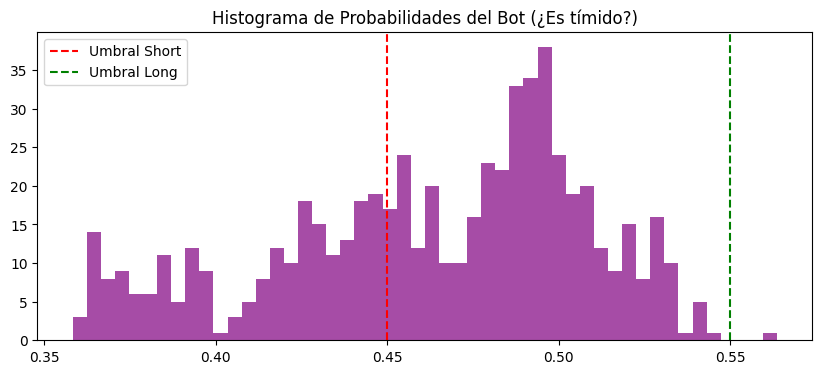

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns # Si no tienes seaborn, usa plt normal

# Obtener predicciones crudas
model.eval()
raw_preds = []
with torch.no_grad():
    for X_b, y_b in test_loader:
        out = model(X_b)
        raw_preds.extend(out.squeeze().tolist())

# Estadísticas básicas
print(f"Predicción Mínima: {min(raw_preds):.4f}")
print(f"Predicción Máxima: {max(raw_preds):.4f}")
print(f"Predicción Media:  {sum(raw_preds)/len(raw_preds):.4f}")

# Histograma
plt.figure(figsize=(10, 4))
plt.hist(raw_preds, bins=50, color='purple', alpha=0.7)
plt.title('Histograma de Probabilidades del Bot (¿Es tímido?)')
plt.axvline(0.45, color='r', linestyle='--', label='Umbral Short')
plt.axvline(0.55, color='g', linestyle='--', label='Umbral Long')
plt.legend()
plt.show()

In [21]:
import joblib
import torch

# 1. Guardar el Modelo (El Cerebro)
torch.save(model.state_dict(), 'trading_bot_v3.pth')
print("Modelo guardado como 'trading_bot_v3.pth'")

# 2. Guardar el Escalador (La Regla)
joblib.dump(scaler, 'scaler.pkl')
print("Escalador guardado como 'scaler.pkl'")

Modelo guardado como 'trading_bot_v3.pth'
Escalador guardado como 'scaler.pkl'
